# Dirichlet-Multinomial Distribution

`DirichletMultinomial(n, alpha)` is the compound of a `Dirichlet` and a `Multinomial`: first draw a probability vector from a `Dirichlet(alpha)`, then draw counts from a `Multinomial(n, that vector)`.

In [1]:
from symbulate import *

## Draw a value

Each draw is a vector of counts, one per category, summing to `n`.

In [2]:
DirichletMultinomial(n=10, alpha=[2, 3, 5]).draw()

(2, 1, 7)

## Simulate

Every simulated value is a vector of counts summing to `n`.

In [3]:
DirichletMultinomial(n=10, alpha=[2, 3, 5]).sim(1000)

0,"(2, 1, 7)"
1,"(2, 3, 5)"
2,"(0, 5, 5)"
3,"(1, 4, 5)"
4,"(1, 3, 6)"
5,"(1, 5, 4)"
6,"(4, 3, 3)"
7,"(2, 5, 3)"
8,"(0, 7, 3)"
...,...
999,"(1, 4, 5)"


## Mean, variance, and standard deviation

The mean count of each category is `n * alpha[i] / sum(alpha)` -- the same as a multinomial whose probabilities are the normalized `alpha`. The variances are inflated by `(n + alpha0) / (1 + alpha0)`.

In [4]:
X = DirichletMultinomial(n=10, alpha=[2, 3, 5])
X.mean(), X.var(), X.sd()

((2.0, 3.0, 5.0),
 (2.909090909090909, 3.8181818181818175, 4.545454545454546),
 (1.7056057308448835, 1.9540168418367887, 2.1320071635561044))

## Covariance matrix

`cov()` returns the full covariance matrix.

In [5]:
X.cov()

array([[ 2.90909091, -1.09090909, -1.81818182],
       [-1.09090909,  3.81818182, -2.72727273],
       [-1.81818182, -2.72727273,  4.54545455]])

## Correlation matrix

`corr()` rescales the covariance into correlations between -1 and 1, with 1 on the diagonal and negative off-diagonal entries.

In [6]:
X.corr()

array([[ 1.        , -0.32732684, -0.5       ],
       [-0.32732684,  1.        , -0.65465367],
       [-0.5       , -0.65465367,  1.        ]])

## Evaluate the probability of an outcome

The probability of a specific set of counts (which must sum to `n`).

In [7]:
DirichletMultinomial(n=10, alpha=[2, 3, 5]).pdf([3, 3, 4])

np.float64(0.030310247028513287)

## Plot the joint distribution

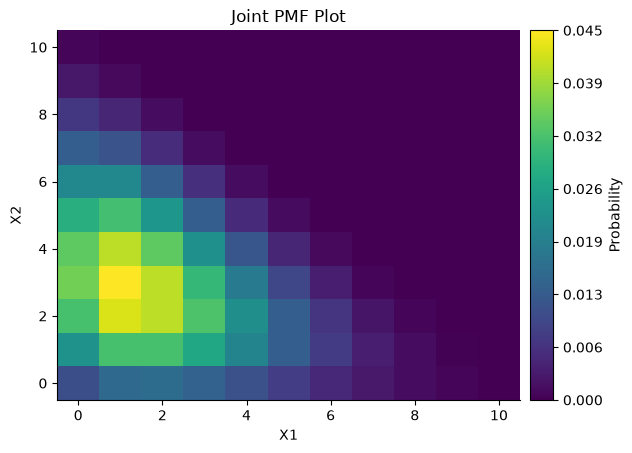

In [8]:
DirichletMultinomial(n=10, alpha=[2, 3, 5]).plot()

## More than three categories: pick a pair with `dims`

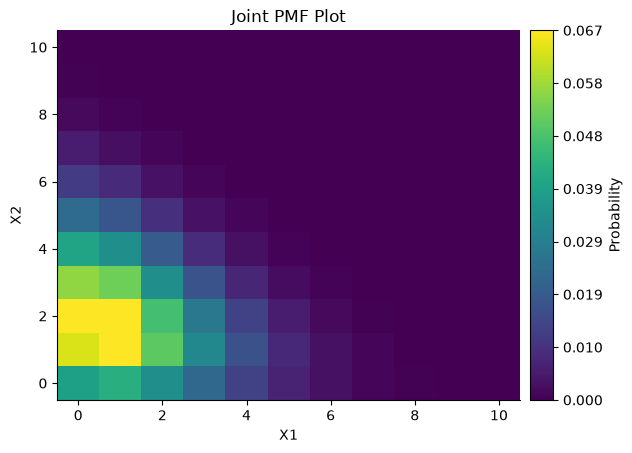

In [9]:
Y = DirichletMultinomial(n=10, alpha=[2, 3, 5, 4])
Y.plot(dims=(0, 1))

## Every pair at once: `pairs=True`

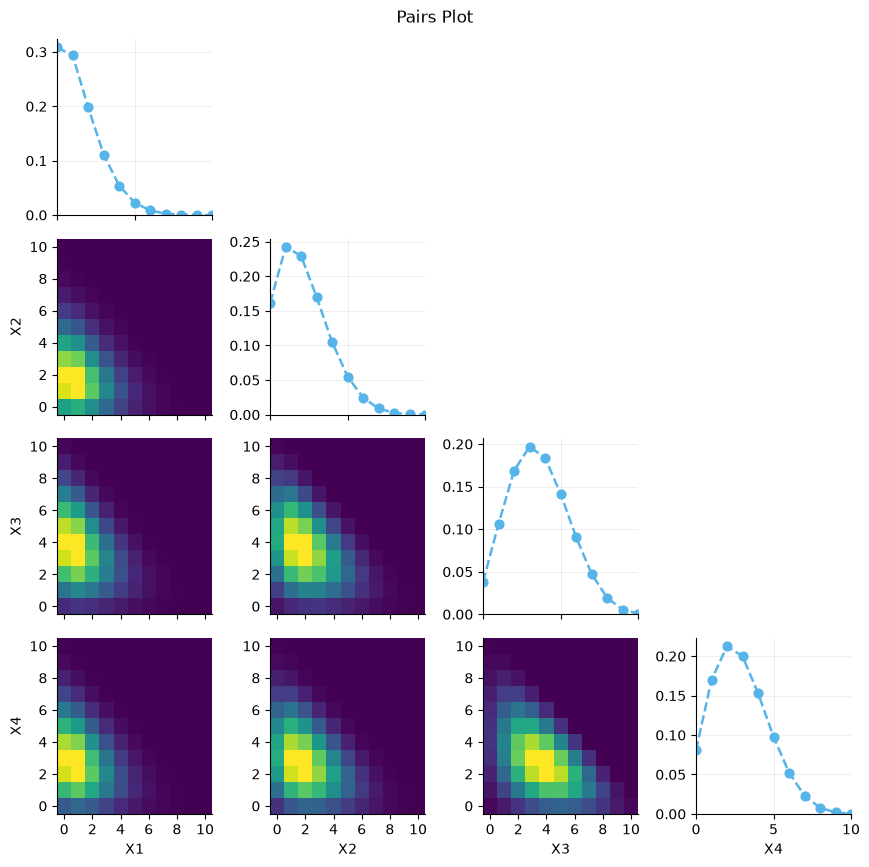

In [10]:
Y.plot(pairs=True)

## Relationship: each count is marginally Beta-Binomial

Focusing on one category (and lumping the rest together) is the univariate compound: count `i` is `BetaBinomial(n, alpha_i, alpha0 - alpha_i)`. Here the first count of `DirichletMultinomial(10, [2, 3, 5])` is `BetaBinomial(10, 2, 8)` (since `alpha0 - alpha_0 = 10 - 2 = 8`).

Currently Showing: Impulse Plot (Default)
Alternative Plots: Histogram (type = "hist"), Dot Plot (type = "dotplot"), ECDF Plot (type = "ecdf")


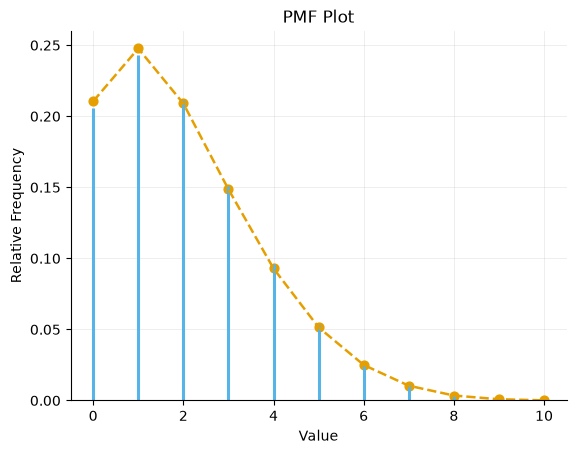

In [11]:
A, B, C = RV(DirichletMultinomial(n=10, alpha=[2, 3, 5]))
A.sim(10000).plot()
BetaBinomial(10, 2, 8).plot()